**Imports and paths**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from PIL import Image

from torchvision import transforms
from torchvision.models import (
    convnext_tiny,
    ConvNeXt_Tiny_Weights
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

PROJECT_ROOT = Path("/content/drive/MyDrive/Dissertation")

SPLIT_DIR = (
    PROJECT_ROOT
    / "03_Data_Processed"
    / "splits"
)

IMAGE_ROOT = (
    PROJECT_ROOT
    / "03_Data_Processed"
    / "mammography_512"
)

IMAGE_CHECKPOINT = (
    PROJECT_ROOT
    / "04_Models"
    / "saved_models"
    / "best_two_view_convnext_tiny.pth"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "05_Results"
    / "late_fusion"
)

FIGURE_DIR = RESULTS_DIR / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Image checkpoint exists:", IMAGE_CHECKPOINT.exists())

Mounted at /content/drive
Image checkpoint exists: True


**Reproducibility**

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


**Load fixed splits**

In [3]:
train_df = pd.read_csv(
    SPLIT_DIR / "train_breast_level.csv"
)

val_df = pd.read_csv(
    SPLIT_DIR / "validation_breast_level.csv"
)

test_df = pd.read_csv(
    SPLIT_DIR / "test_breast_level.csv"
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 1444
Validation: 309
Test: 317


**Part A — Clinical probabilities — Recreate selected clinical pipeline**

In [4]:
numeric_features = [
    "age",
    "bi_rads"
]

categorical_features = [
    "breast_density",
    "breast_side"
]

all_features = (
    numeric_features
    + categorical_features
)

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(handle_unknown="ignore")
    )
])

clinical_preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

clinical_model = Pipeline([
    (
        "preprocessor",
        clinical_preprocessor
    ),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

**Fit on TRAIN only**

In [5]:
X_train = train_df[all_features]
y_train = train_df["target"]

X_val = val_df[all_features]
y_val = val_df["target"]

X_test = test_df[all_features]
y_test = test_df["target"]

clinical_model.fit(
    X_train,
    y_train
)

clinical_val_prob = (
    clinical_model.predict_proba(X_val)[:, 1]
)

clinical_test_prob = (
    clinical_model.predict_proba(X_test)[:, 1]
)

print(
    "Clinical validation ROC-AUC:",
    roc_auc_score(
        y_val,
        clinical_val_prob
    )
)

print(
    "Clinical test ROC-AUC:",
    roc_auc_score(
        y_test,
        clinical_test_prob
    )
)

Clinical validation ROC-AUC: 0.974456289978678
Clinical test ROC-AUC: 0.9814081319214292


**Part B — Image probabilities — Build image paths**

In [6]:
def add_image_paths(dataframe):

    dataframe = dataframe.copy()

    dataframe["view1_path"] = dataframe.apply(
        lambda row:
        str(
            IMAGE_ROOT
            / row["split"]
            / row["patient_breast_id"]
            / "view_1.png"
        ),
        axis=1
    )

    dataframe["view2_path"] = dataframe.apply(
        lambda row:
        str(
            IMAGE_ROOT
            / row["split"]
            / row["patient_breast_id"]
            / "view_2.png"
        ),
        axis=1
    )

    return dataframe


val_image_df = add_image_paths(
    val_df
)

test_image_df = add_image_paths(
    test_df
)

print(
    "Missing validation View 1:",
    (~val_image_df["view1_path"]
     .apply(lambda x: Path(x).exists()))
    .sum()
)

print(
    "Missing test View 1:",
    (~test_image_df["view1_path"]
     .apply(lambda x: Path(x).exists()))
    .sum()
)

Missing validation View 1: 0
Missing test View 1: 0


**Evaluation transforms**

In [7]:
IMAGE_SIZE = 224

eval_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

**Two-view dataset**

In [8]:
class TwoViewDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.transform = transform


    def __len__(self):

        return len(self.df)


    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        view1 = Image.open(
            row["view1_path"]
        ).convert("L")

        view2 = Image.open(
            row["view2_path"]
        ).convert("L")

        if self.transform:

            view1 = self.transform(view1)
            view2 = self.transform(view2)

        label = torch.tensor(
            int(row["target"]),
            dtype=torch.long
        )

        return (
            view1,
            view2,
            label,
            row["patient_breast_id"]
        )

**ConvNeXt architecture**

In [9]:
class TwoViewConvNeXt(nn.Module):

    def __init__(self):

        super().__init__()

        weights = ConvNeXt_Tiny_Weights.DEFAULT

        backbone = convnext_tiny(
            weights=weights
        )

        feature_dim = (
            backbone.classifier[2].in_features
        )

        backbone.classifier[2] = nn.Identity()

        self.backbone = backbone

        self.classifier = nn.Sequential(
            nn.Linear(
                feature_dim * 2,
                512
            ),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(
                512,
                2
            )
        )


    def forward(
        self,
        view1,
        view2
    ):

        feature1 = self.backbone(view1)
        feature2 = self.backbone(view2)

        combined = torch.cat(
            [feature1, feature2],
            dim=1
        )

        return self.classifier(
            combined
        )

**DataLoaders**

In [10]:
val_dataset = TwoViewDataset(
    val_image_df,
    transform=eval_transform
)

test_dataset = TwoViewDataset(
    test_image_df,
    transform=eval_transform
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

**Load selected image model**

In [11]:
image_model = TwoViewConvNeXt().to(
    device
)

image_model.load_state_dict(
    torch.load(
        IMAGE_CHECKPOINT,
        map_location=device
    )
)

image_model.eval()

print("Selected image model loaded.")

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:01<00:00, 112MB/s]


Selected image model loaded.


**Probability extraction**

In [12]:
def get_image_probabilities(
    model,
    loader
):

    model.eval()

    probabilities = []
    labels_all = []
    ids_all = []

    with torch.no_grad():

        for (
            view1,
            view2,
            labels,
            breast_ids
        ) in loader:

            view1 = view1.to(device)
            view2 = view2.to(device)

            outputs = model(
                view1,
                view2
            )

            probs = torch.softmax(
                outputs,
                dim=1
            )[:, 1]

            probabilities.extend(
                probs.cpu().numpy()
            )

            labels_all.extend(
                labels.numpy()
            )

            ids_all.extend(
                breast_ids
            )

    return pd.DataFrame({
        "patient_breast_id":
            ids_all,

        "target":
            labels_all,

        "image_probability":
            probabilities
    })


image_val_predictions = (
    get_image_probabilities(
        image_model,
        val_loader
    )
)

image_test_predictions = (
    get_image_probabilities(
        image_model,
        test_loader
    )
)

print(
    "Image validation ROC-AUC:",
    roc_auc_score(
        image_val_predictions["target"],
        image_val_predictions[
            "image_probability"
        ]
    )
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Image validation ROC-AUC: 0.863539445628998


**Part C — Match clinical + image probabilities — Create clinical prediction tables**

In [13]:
clinical_val_predictions = pd.DataFrame({
    "patient_breast_id":
        val_df["patient_breast_id"].values,

    "target":
        val_df["target"].values,

    "clinical_probability":
        clinical_val_prob
})

clinical_test_predictions = pd.DataFrame({
    "patient_breast_id":
        test_df["patient_breast_id"].values,

    "target":
        test_df["target"].values,

    "clinical_probability":
        clinical_test_prob
})

**Merge modalities**

In [14]:
val_fusion = clinical_val_predictions.merge(
    image_val_predictions[
        [
            "patient_breast_id",
            "image_probability"
        ]
    ],
    on="patient_breast_id",
    how="inner",
    validate="one_to_one"
)

test_fusion = clinical_test_predictions.merge(
    image_test_predictions[
        [
            "patient_breast_id",
            "image_probability"
        ]
    ],
    on="patient_breast_id",
    how="inner",
    validate="one_to_one"
)

print("Validation fusion records:", len(val_fusion))
print("Test fusion records:", len(test_fusion))

Validation fusion records: 309
Test fusion records: 317


**Part D — Validation-only weight search — Search weights**

In [15]:
weights = np.arange(
    0.0,
    1.01,
    0.05
)

weight_results = []

for alpha in weights:

    fused_prob = (
        alpha
        * val_fusion[
            "clinical_probability"
        ]
        +
        (1 - alpha)
        * val_fusion[
            "image_probability"
        ]
    )

    roc_auc_value = roc_auc_score(
        val_fusion["target"],
        fused_prob
    )

    pr_auc_value = average_precision_score(
        val_fusion["target"],
        fused_prob
    )

    weight_results.append({
        "clinical_weight":
            alpha,

        "image_weight":
            1 - alpha,

        "validation_roc_auc":
            roc_auc_value,

        "validation_pr_auc":
            pr_auc_value
    })


weight_results_df = pd.DataFrame(
    weight_results
)

weight_results_df = (
    weight_results_df
    .sort_values(
        "validation_roc_auc",
        ascending=False
    )
)

display(
    weight_results_df.head(10)
)

,clinical_weight,image_weight,validation_roc_auc,validation_pr_auc
20,1.00,0.00,0.974456,0.980227
19,0.95,0.05,0.974328,0.980478
18,0.90,0.10,0.973561,0.979584
17,0.85,0.15,0.971812,0.977928
16,0.80,0.20,0.970149,0.976352
15,0.75,0.25,0.967420,0.973949
14,0.70,0.30,0.963454,0.970740
13,0.65,0.35,0.960000,0.967925
12,0.60,0.40,0.956631,0.965352
11,0.55,0.45,0.954499,0.963598


**Select best weight**

In [16]:
best_weight_row = (
    weight_results_df.iloc[0]
)

BEST_CLINICAL_WEIGHT = float(
    best_weight_row[
        "clinical_weight"
    ]
)

BEST_IMAGE_WEIGHT = float(
    best_weight_row[
        "image_weight"
    ]
)

print("=" * 70)
print("SELECTED LATE-FUSION WEIGHTS")
print("=" * 70)

print(
    "Clinical weight:",
    BEST_CLINICAL_WEIGHT
)

print(
    "Image weight:",
    BEST_IMAGE_WEIGHT
)

print(
    "Validation ROC-AUC:",
    round(
        best_weight_row[
            "validation_roc_auc"
        ],
        4
    )
)

print(
    "Validation PR-AUC:",
    round(
        best_weight_row[
            "validation_pr_auc"
        ],
        4
    )
)

SELECTED LATE-FUSION WEIGHTS
Clinical weight: 1.0
Image weight: 0.0
Validation ROC-AUC: 0.9745
Validation PR-AUC: 0.9802


**Save validation weight search**

In [17]:
weight_results_df.to_csv(
    RESULTS_DIR
    / "late_fusion_validation_weight_search.csv",
    index=False
)

**Part E — Test evaluation — Apply locked weight to test set**

In [18]:
test_fusion[
    "late_fusion_probability"
] = (
    BEST_CLINICAL_WEIGHT
    * test_fusion[
        "clinical_probability"
    ]
    +
    BEST_IMAGE_WEIGHT
    * test_fusion[
        "image_probability"
    ]
)

test_fusion[
    "prediction"
] = (
    test_fusion[
        "late_fusion_probability"
    ]
    >= 0.5
).astype(int)

**Final metrics**

In [19]:
y_true = (
    test_fusion[
        "target"
    ].values
)

y_pred = (
    test_fusion[
        "prediction"
    ].values
)

y_prob = (
    test_fusion[
        "late_fusion_probability"
    ].values
)

tn, fp, fn, tp = confusion_matrix(
    y_true,
    y_pred
).ravel()

specificity = (
    tn / (tn + fp)
)

late_fusion_metrics = {

    "accuracy":
        accuracy_score(
            y_true,
            y_pred
        ),

    "precision":
        precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

    "recall":
        recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

    "specificity":
        specificity,

    "f1":
        f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

    "roc_auc":
        roc_auc_score(
            y_true,
            y_prob
        ),

    "pr_auc":
        average_precision_score(
            y_true,
            y_prob
        ),

    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp
}

print("=" * 70)
print("FINAL LATE-FUSION TEST RESULTS")
print("=" * 70)

for key, value in late_fusion_metrics.items():

    if isinstance(
        value,
        (float, np.floating)
    ):

        print(
            f"{key}: {value:.4f}"
        )

    else:

        print(
            f"{key}: {value}"
        )

FINAL LATE-FUSION TEST RESULTS
accuracy: 0.9338
precision: 0.9243
recall: 0.9607
specificity: 0.8993
f1: 0.9421
roc_auc: 0.9814
pr_auc: 0.9837
TN: 125
FP: 14
FN: 7
TP: 171


**Save results**

In [20]:
late_fusion_metrics_df = pd.DataFrame([
    {
        "model":
            "Probability-level Late Fusion",

        "clinical_weight":
            BEST_CLINICAL_WEIGHT,

        "image_weight":
            BEST_IMAGE_WEIGHT,

        "weight_selection":
            "Validation ROC-AUC",

        **late_fusion_metrics
    }
])

late_fusion_metrics_df.to_csv(
    RESULTS_DIR
    / "final_late_fusion_test_metrics.csv",
    index=False
)

test_fusion.to_csv(
    RESULTS_DIR
    / "final_late_fusion_test_predictions.csv",
    index=False
)

print("Late-fusion results saved.")

Late-fusion results saved.


**Weight-search visualisation**

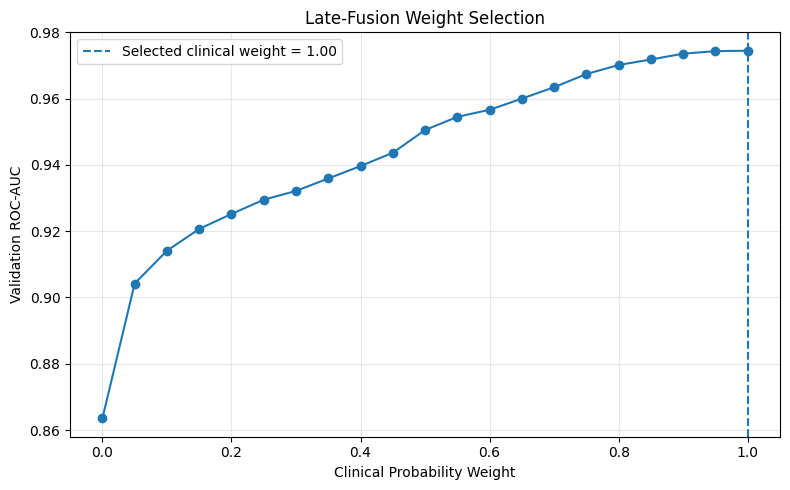

In [21]:
weight_plot = (
    weight_results_df
    .sort_values(
        "clinical_weight"
    )
)

plt.figure(figsize=(8, 5))

plt.plot(
    weight_plot[
        "clinical_weight"
    ],
    weight_plot[
        "validation_roc_auc"
    ],
    marker="o"
)

plt.axvline(
    BEST_CLINICAL_WEIGHT,
    linestyle="--",
    label=(
        f"Selected clinical weight "
        f"= {BEST_CLINICAL_WEIGHT:.2f}"
    )
)

plt.xlabel(
    "Clinical Probability Weight"
)

plt.ylabel(
    "Validation ROC-AUC"
)

plt.title(
    "Late-Fusion Weight Selection"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "01_late_fusion_weight_search.png",
    dpi=300
)

plt.show()